# 01 — Data Preparation & Feature Audit


## 1. Imports & config

In [13]:
import warnings; warnings.filterwarnings("ignore")
import json, os, time
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy.sparse import csgraph
import matplotlib.pyplot as plt

from common import (ECO_TITLES, GRAPH_FEATURES, MIN_VIEW_POS, SEED,
                    compute_graph_features, read_csv_literal)

ECO       = os.environ.get("ECO", "npm")
ECO_TITLE = ECO_TITLES[ECO]
ROOT      = Path("..")
DATA_DIR  = ROOT / "data" / "input" / ECO
OUT_DIR   = ROOT / "data" / "output" / ECO / "01_data_prep"
OUT_DIR.mkdir(parents=True, exist_ok=True)

t_nb = time.time()
print(f"{ECO_TITLE} | out: {OUT_DIR.resolve()}")


npm | out: C:\Users\amehs\Documents\ThesisAppendixVersion\data\output\npm\01_data_prep


## 2. Load, de-duplicate, filter

In [2]:
df = read_csv_literal(DATA_DIR / "all_features.csv", encoding="utf-8")
n_raw = len(df)
df = df.drop_duplicates(subset="package", keep="first")
n_dedup = len(df)
df = df[df["status"] == "ok"].reset_index(drop=True)
if ECO == "npm":
    # npm exposes a single bugs URL; issueslink_* mirrors bugslink_*
    df["issueslink_exist"] = df["bugslink_exist"]
    df["issueslink_length"] = df["bugslink_length"]

N = len(df)
label_arr = df["label"].astype(int).to_numpy()
m_clean, m_vuln, m_comp = (label_arr == 0), (label_arr == -1), (label_arr == 1)

print(f"rows raw            : {n_raw:,}")
print(f"after dedup(package): {n_dedup:,}  (removed {n_raw-n_dedup:,})")
print(f"after status == ok  : {N:,}  (removed {n_dedup-N:,})")
print(f"labels: clean {int(m_clean.sum()):,} | vulnerable {int(m_vuln.sum()):,} | "
      f"compromised {int(m_comp.sum()):,}")
assert df["package"].is_unique, "package key is not unique after dedup"
assert N > 0


rows raw            : 101,361
after dedup(package): 101,361  (removed 0)
after status == ok  : 101,350  (removed 11)
labels: clean 96,265 | vulnerable 2,931 | compromised 2,154


## 3. Feature schema and what each feature means

In [3]:
ECO_CONFIG = {
    "npm": {
        "etm": [
            "name_exist",
            "name_length",
            "dist_tags_exist",
            "dist_tags_length",
            "versions_exist",
            "versions_length",
            "versions_num_count",
            "maintainers_exist",
            "description_exist",
            "description_length",
            "readme_exist",
            "readme_length",
            "author_exist",
            "author_name",
            "author_email",
            "license_exist",
            "license_length",
            "keywords_exist",
            "keywords_length",
            "keywords_num_count",
            "homepage_exist",
            "homepage_length",
            "github_exist",
            "github_length",
            "bugslink_exist",
            "bugslink_length",
            "issueslink_exist",
            "issueslink_length",
            "dependencies_exist",
            "dependencies_length",
            "scripts_exist",
            "scripts_length",
            "devDependencies_exist",
            "devDependencies_length",
            "directories_exist",
            "directories_length",
        ],
        "dtm": [
            "package_age_days",
            "package_modified_duration_days",
            "package_published_duration_days",
            "author_CPN",
            "author_service_time",
            "author_CCS",
            "maintainer_CPN",
            "maintainer_service_time",
            "maintainer_CCS",
            "contributor_CPN",
            "contributor_service_time",
            "contributor_CCS",
            "publisher_CPN",
            "publisher_service_time",
            "publisher_CCS",
            "pull_request",
            "issues",
            "fork_number",
            "star",
            "subscriber_count",
        ],
    },
    "pypi": {
        "etm": [
            "name_exist",
            "name_length",
            "versions_exist",
            "versions_length",
            "versions_num_count",
            "maintainers_exist",
            "description_exist",
            "description_length",
            "readme_exist",
            "readme_length",
            "author_exist",
            "author_name",
            "author_email",
            "license_exist",
            "license_length",
            "keywords_exist",
            "keywords_length",
            "keywords_num_count",
            "homepage_exist",
            "homepage_length",
            "github_exist",
            "github_length",
            "bugslink_exist",
            "bugslink_length",
            "dependencies_exist",
            "dependencies_length",
        ],
        "dtm": [
            "package_age_days",
            "package_modified_duration_days",
            "package_published_duration_days",
            "author_CPN",
            "author_service_time",
            "author_CCS",
            "maintainer_CPN",
            "maintainer_service_time",
            "maintainer_CCS",
            "star",
            "fork_number",
            "subscriber_count",
            "issues",
            "pull_request",
        ],
    },
    "maven": {
        "etm": [
            "name_exist",
            "name_length",
            "versions_exist",
            "versions_length",
            "versions_num_count",
            "description_exist",
            "description_length",
            "author_exist",
            "author_name",
            "author_email",
            "license_exist",
            "license_length",
            "homepage_exist",
            "homepage_length",
            "github_exist",
            "github_length",
            "bugslink_exist",
            "bugslink_length",
            "dependencies_exist",
            "dependencies_length",
            "devDependencies_exist",
            "devDependencies_length",
        ],
        "dtm": [
            "package_age_days",
            "package_modified_duration_days",
            "package_published_duration_days",
            "author_CPN",
            "author_service_time",
            "author_CCS",
            "developer_CPN",
            "developer_service_time",
            "developer_CCS",
            "star",
            "fork_number",
            "subscriber_count",
            "issues",
            "pull_request",
        ],
    },
}

ETM_FEATURES = ECO_CONFIG[ECO]["etm"]
DTM_FEATURES = ECO_CONFIG[ECO]["dtm"]

META_FEATURES = ETM_FEATURES + DTM_FEATURES
missing_cols = [f for f in META_FEATURES if f not in df.columns]
assert not missing_cols, f"schema mismatch, absent from all_features.csv: {missing_cols}"

FEATURE_DOC = {
    # ---- naming conventions (data/memptec/<eco>/README.md) ----
    "_exist":     "presence flag for the field (1 = present in the pinned version's metadata)",
    "_length":    "character length of the field; for dict/list fields, of the JSON-serialised value",
    "_num_count": "number of elements in the field",
    # ---- specific fields ----
    "author_name":  "presence flag for the author name (NOT the raw string)",
    "author_email": "presence flag for the author email (NOT the raw string)",
    "package_age_days": "days from package creation to the extraction date",
    "package_modified_duration_days": "days since the last metadata/release modification event",
    "package_published_duration_days": "days since the pinned version was published",
    "_CPN":          "Count of Packages by that stakeholder, WITHIN this dataset only",
    "_service_time": "how long the stakeholder has been active",
    "_CCS":          "Contribution Score = log2(service_time) * log2(CPN)",
    "star":             "GitHub stargazers (current-time count, not as of the pinned version)",
    "fork_number":      "GitHub forks (current-time count)",
    "subscriber_count": "GitHub watchers (current-time count)",
    "issues":           "GitHub issue count (current-time count)",
    "pull_request":     "GitHub pull-request count (current-time count)",
}

def describe(feat):
    if feat in FEATURE_DOC:
        return FEATURE_DOC[feat]
    for suffix in ("_num_count", "_service_time", "_CPN", "_CCS", "_length", "_exist"):
        if feat.endswith(suffix):
            return f"{feat.split(suffix)[0]}: {FEATURE_DOC[suffix]}"
    return "(undocumented)"


print(f"ETM {len(ETM_FEATURES)} | DTM {len(DTM_FEATURES)} | metadata total {len(META_FEATURES)}\n")
for grp, feats in [("ETM", ETM_FEATURES), ("DTM", DTM_FEATURES)]:
    print(f"--- {grp} ---")
    for f in feats:
        print(f"  {f:34s} {describe(f)}")
    print()

ETM 36 | DTM 20 | metadata total 56

--- ETM ---
  name_exist                         name: presence flag for the field (1 = present in the pinned version's metadata)
  name_length                        name: character length of the field; for dict/list fields, of the JSON-serialised value
  dist_tags_exist                    dist_tags: presence flag for the field (1 = present in the pinned version's metadata)
  dist_tags_length                   dist_tags: character length of the field; for dict/list fields, of the JSON-serialised value
  versions_exist                     versions: presence flag for the field (1 = present in the pinned version's metadata)
  versions_length                    versions: character length of the field; for dict/list fields, of the JSON-serialised value
  versions_num_count                 versions: number of elements in the field
  maintainers_exist                  maintainers: presence flag for the field (1 = present in the pinned version's metadata)


## 4. Missingness audit

In [4]:
num = df[META_FEATURES].apply(pd.to_numeric, errors="coerce")
n_coerced = int((num.isna() & df[META_FEATURES].notna()).sum().sum())

audit = pd.DataFrame({
    "feature": META_FEATURES,
    "group": ["ETM" if f in ETM_FEATURES else "DTM" for f in META_FEATURES],
    "description": [describe(f) for f in META_FEATURES],
    "n_missing": [int(num[f].isna().sum()) for f in META_FEATURES],
    "n_unique": [int(num[f].nunique(dropna=True)) for f in META_FEATURES],
    "min": [float(num[f].min()) if num[f].notna().any() else np.nan for f in META_FEATURES],
    "median": [float(num[f].median()) if num[f].notna().any() else np.nan for f in META_FEATURES],
    "max": [float(num[f].max()) if num[f].notna().any() else np.nan for f in META_FEATURES],
})
audit["pct_missing"] = (100 * audit["n_missing"] / N).round(3)
audit["constant"] = audit["n_unique"] <= 1
audit = audit[["feature", "group", "n_missing", "pct_missing", "n_unique", "constant",
               "min", "median", "max", "description"]]

print(f"values coerced to NaN because they were non-numeric: {n_coerced:,}")
nz = audit[audit.n_missing > 0].sort_values("pct_missing", ascending=False)
if len(nz):
    print(f"\n{len(nz)} of {len(META_FEATURES)} features have missing values:")
    print(nz[["feature", "group", "n_missing", "pct_missing"]].to_string(index=False))
else:
    print("\nNo missing values in any metadata feature.")

const = audit[audit.constant]
if len(const):
    print(f"\nCONSTANT features (no discriminative content, kept for schema fidelity): "
          f"{list(const.feature)}")

values coerced to NaN because they were non-numeric: 0

5 of 56 features have missing values:
         feature group  n_missing  pct_missing
    pull_request   DTM      22811       22.507
          issues   DTM      22811       22.507
     fork_number   DTM      22811       22.507
            star   DTM      22811       22.507
subscriber_count   DTM      22811       22.507

CONSTANT features (no discriminative content, kept for schema fidelity): ['name_exist', 'dist_tags_exist', 'versions_exist']


Blocks of features that go missing on exactly the same rows:
   22,811 rows (22.51%)  <- 5 feature(s): ['pull_request', 'issues', 'fork_number', 'star', 'subscriber_count']

POLICY: left as NaN. A block like this is one absent upstream source, not noise —
zero-filling it would make 'source absent' numerically identical to 'source present,
value zero'. Notebook 02 imputes explicitly inside the pipelines that require it.


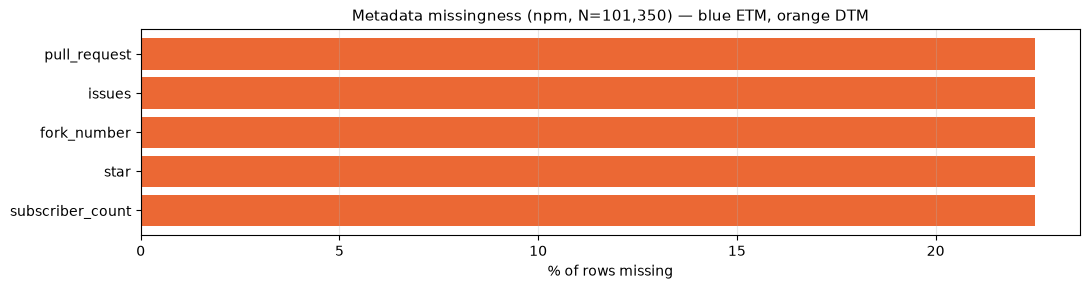

In [5]:
# co-missingness: group features by their exact missing-row signature
sig = {}
for f in META_FEATURES:
    key = num[f].isna().values.tobytes()
    sig.setdefault(key, []).append(f)
blocks = [(fs, int(num[fs[0]].isna().sum())) for fs in sig.values() if int(num[fs[0]].isna().sum()) > 0]
blocks.sort(key=lambda t: -t[1])

if blocks:
    print("Blocks of features that go missing on exactly the same rows:")
    for fs, n_miss in blocks:
        print(f"  {n_miss:>7,} rows ({100*n_miss/N:5.2f}%)  <- {len(fs)} feature(s): {fs}")
    print("\nPOLICY: left as NaN. A block like this is one absent upstream source, not noise —")
    print("zero-filling it would make 'source absent' numerically identical to 'source present,")
    print("value zero'. Notebook 02 imputes explicitly inside the pipelines that require it.")
else:
    print("No co-missing blocks.")

fig, ax = plt.subplots(figsize=(11, max(3, 0.17 * len(nz) + 1.2)))
if len(nz):
    ax.barh(nz["feature"][::-1], nz["pct_missing"][::-1],
            color=["#2a78d6" if g == "ETM" else "#eb6834" for g in nz["group"]][::-1])
    ax.set_xlabel("% of rows missing")
else:
    ax.text(0.5, 0.5, "no missing values", ha="center", va="center", transform=ax.transAxes)
    ax.set_xticks([])
ax.set_title(f"Metadata missingness ({ECO_TITLE}, N={N:,}) — blue ETM, orange DTM", fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "missingness.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)

## 5. Label views

In [6]:
views = {}
# compromised: vulnerable rows are DROPPED, not relabelled clean
keep_comp = ~m_vuln
views["compromised"] = {"keep": keep_comp, "y": m_comp[keep_comp].astype(np.int64)}
# risky: vulnerable joins compromised as a positive
views["risky"] = {"keep": np.ones(N, bool), "y": (m_comp | m_vuln).astype(np.int64)}

view_rows = []
for name, v in views.items():
    n_v, n_pos = int(v["keep"].sum()), int(v["y"].sum())
    view_rows.append({"view": name, "n_rows": n_v, "n_positive": n_pos,
                      "n_negative": n_v - n_pos, "prevalence": n_pos / n_v,
                      "usable": n_pos >= MIN_VIEW_POS})
views_df = pd.DataFrame(view_rows)
print(views_df.to_string(index=False, float_format="{:.5f}".format))
for _, r in views_df.iterrows():
    if not r["usable"]:
        print(f"\nNOTE: the '{r['view']}' view has only {r['n_positive']} positive(s) — below "
              f"MIN_VIEW_POS={MIN_VIEW_POS}. Downstream notebooks will skip it for {ECO_TITLE}.")

       view  n_rows  n_positive  n_negative  prevalence  usable
compromised   98419        2154       96265     0.02189    True
      risky  101350        5085       96265     0.05017    True


## 6. Dependency graph substrate and the canonical 11 structural features

In [7]:
assert len(GRAPH_FEATURES) == 11
print("graph helpers defined; canonical set =", GRAPH_FEATURES)


graph helpers defined; canonical set = ['warfield_level', 'in_degree', 'out_degree', 'log1p_driving_power', 'log1p_dependence_power', 'scc_size', 'pagerank', 'hits_hub', 'hits_auth', 'clustering', 'closeness']


In [8]:
edges = read_csv_literal(DATA_DIR / "graph_edges.csv")
pos = {p: i for i, p in enumerate(df["package"])}
s_ser = edges["source"].map(pos); t_ser = edges["target"].map(pos)
valid = s_ser.notna() & t_ser.notna()
n_dropped_edges = int((~valid).sum())
src = s_ser[valid].astype(np.int64).to_numpy()
tgt = t_ser[valid].astype(np.int64).to_numpy()

t0 = time.time()
graph_df, ex = compute_graph_features(src, tgt, N)
conn_pkg, scc = ex["conn"], ex["scc"]

print(f"edges kept {len(src):,} (dropped {n_dropped_edges:,}: an endpoint left the corpus at "
      f"dedup/status filtering)")
print(f"connected {int(conn_pkg.sum()):,} / {N:,} | SCCs {ex['n_scc']:,} | "
      f"max Warfield level {int(graph_df['warfield_level'].max())} ({time.time()-t0:.0f}s)")
print(f"\nstructural feature summary:")
print(graph_df.describe().T[["mean", "std", "min", "50%", "max"]]
      .to_string(float_format="{:.4f}".format))
assert np.isfinite(graph_df.values).all(), "non-finite structural feature"
assert graph_df.shape == (N, 11)

  reachability [driving] 47.3s
  reachability [dependence] 41.1s
edges kept 388,416 (dropped 0: an endpoint left the corpus at dedup/status filtering)
connected 85,279 / 101,350 | SCCs 100,415 | max Warfield level 151 (127s)

structural feature summary:
                         mean     std    min    50%       max
warfield_level         4.0870  7.0686 0.0000 2.0000  151.0000
in_degree              3.8324 35.0985 0.0000 0.0000 4729.0000
out_degree             3.8324  8.1796 0.0000 2.0000  256.0000
log1p_driving_power    1.0047  1.4805 0.0000 0.0000    9.4631
log1p_dependence_power 1.8306  1.7368 0.0000 1.3863    7.4091
scc_size               1.0971  1.2220 1.0000 1.0000   30.0000
pagerank               0.0000  0.0001 0.0000 0.0000    0.0137
hits_hub               0.0001  0.0031 0.0000 0.0000    0.1211
hits_auth              0.0001  0.0031 0.0000 0.0000    0.1189
clustering             0.1721  0.2905 0.0000 0.0000    1.0000
closeness              0.1824  0.0962 0.0000 0.2203    0.3908


## 7. Save artifacts

In [9]:
model_ready = pd.concat([df[["package"]].reset_index(drop=True),
                         pd.Series(label_arr, name="label"),
                         num.reset_index(drop=True)], axis=1)
model_ready.to_csv(OUT_DIR / "model_ready_dataset.csv", index=False, encoding="utf-8")

graph_out = pd.concat([df[["package"]].reset_index(drop=True),
                       pd.Series(scc, name="scc_id"),
                       pd.Series(conn_pkg, name="connected"),
                       graph_df.reset_index(drop=True)], axis=1)
graph_out.to_csv(OUT_DIR / "graph_features.csv", index=False, encoding="utf-8")

edges_out = pd.DataFrame({"source": df["package"].to_numpy()[src],
                          "target": df["package"].to_numpy()[tgt]})
edges_out.to_csv(OUT_DIR / "edges.csv", index=False, encoding="utf-8")

audit.to_csv(OUT_DIR / "feature_audit.csv", index=False, encoding="utf-8")

# Retired from the canonical set; notebook 05 alone reloads this for its second impact currency.
if "global_dependent_packages_count" in df.columns:
    gdc_top = pd.to_numeric(df["global_dependent_packages_count"], errors="coerce")
else:
    # maven's all_features.csv has no global_dependent_packages_count column; use top_packages.csv
    top = read_csv_literal(DATA_DIR / "top_packages.csv").drop_duplicates("package").set_index("package")
    gdc_top = pd.to_numeric(df["package"].map(top["dependent_packages_count"]), errors="coerce")
fill_path = DATA_DIR / "dependent_counts_fill.csv"
if fill_path.exists():
    fill = read_csv_literal(fill_path)
    fmap = pd.to_numeric(fill.drop_duplicates("package", keep="last")
                             .set_index("package")["dependent_packages_count"], errors="coerce")
    gdc_fill = df["package"].map(fmap)
else:
    gdc_fill = pd.Series(np.nan, index=df.index)
global_deps = gdc_top.fillna(gdc_fill).fillna(0).to_numpy(dtype=np.float64)
pd.DataFrame({"package": df["package"].to_numpy(), "global_dependents": global_deps}) \
  .to_csv(OUT_DIR / "global_dependents.csv", index=False, encoding="utf-8")

schema = {
    "ecosystem": ECO,
    "n_packages": int(N),
    "seed": SEED,
    "etm_features": ETM_FEATURES,
    "dtm_features": DTM_FEATURES,
    "meta_features": META_FEATURES,
    "graph_features": GRAPH_FEATURES,
    "label_views": {r["view"]: {"n_rows": int(r["n_rows"]),
                                "n_positive": int(r["n_positive"]),
                                "prevalence": float(r["prevalence"]),
                                "usable": bool(r["usable"])}
                    for _, r in views_df.iterrows()},
    "label_counts": {"clean": int(m_clean.sum()), "vulnerable": int(m_vuln.sum()),
                     "compromised": int(m_comp.sum())},
    "n_edges": int(len(src)),
    "n_connected": int(conn_pkg.sum()),
    "missing_policy": "NaN preserved; imputation is explicit in the consuming pipeline",
}
(OUT_DIR / "schema.json").write_text(json.dumps(schema, indent=2), encoding="utf-8")

for f in ["model_ready_dataset.csv", "graph_features.csv", "edges.csv",
          "feature_audit.csv", "global_dependents.csv", "schema.json"]:
    p = OUT_DIR / f
    print(f"  saved {f:28s} {p.stat().st_size/1e6:7.2f} MB")

  saved model_ready_dataset.csv        29.66 MB
  saved graph_features.csv             14.85 MB
  saved edges.csv                      14.25 MB
  saved feature_audit.csv               0.01 MB
  saved global_dependents.csv           2.49 MB
  saved schema.json                     0.00 MB


## 8. Verification

In [10]:
# (1) the saved artifacts round-trip and stay aligned on the package key
mr = read_csv_literal(OUT_DIR / "model_ready_dataset.csv")
gf = read_csv_literal(OUT_DIR / "graph_features.csv")
gd = read_csv_literal(OUT_DIR / "global_dependents.csv")
assert len(mr) == len(gf) == len(gd) == N
assert (mr["package"] == gf["package"]).all() and (mr["package"] == gd["package"]).all()
assert mr["package"].is_unique
print(f"[1] three artifacts round-trip, aligned on a unique package key ({N:,} rows)")

# (2) NaN survived the CSV round-trip (the whole point of the missingness policy)
n_nan_before = int(num.isna().sum().sum())
n_nan_after  = int(mr[META_FEATURES].isna().sum().sum())
assert n_nan_before == n_nan_after, (n_nan_before, n_nan_after)
print(f"[2] {n_nan_after:,} NaN values preserved through the round-trip (not zero-filled)")

# (3) schema contract
sch = json.loads((OUT_DIR / "schema.json").read_text(encoding="utf-8"))
assert sch["graph_features"] == GRAPH_FEATURES and len(sch["graph_features"]) == 11
assert list(gf.columns) == ["package", "scc_id", "connected"] + GRAPH_FEATURES
assert set(sch["meta_features"]).issubset(set(mr.columns))
print(f"[3] schema.json pins {len(sch['graph_features'])} structural + "
      f"{len(sch['meta_features'])} metadata features")

# (4) no retired feature leaked into the canonical set
for banned in ("global", "degree", "is_isolated"):
    assert not any(g == banned or g.endswith("_global") or g == "degree"
                   for g in GRAPH_FEATURES), banned
assert "global_dependents" not in gf.columns
print("[4] no global-dependents / redundant column inside the canonical 11")

# (5) label views partition correctly
assert int(views["compromised"]["keep"].sum()) == N - int(m_vuln.sum())
assert int(views["compromised"]["y"].sum()) == int(m_comp.sum())
assert int(views["risky"]["y"].sum()) == int(m_comp.sum()) + int(m_vuln.sum())
print("[5] label views: compromised drops all vulnerable rows; risky merges them as positives")

# (6) graph invariants
lev_all = gf["warfield_level"].to_numpy()
assert (lev_all[~gf["connected"].to_numpy()] == 0).all(), "isolated node at a non-zero level"
de = ex["gs"]["dag_edges"]
if len(de):
    assert np.all(ex["gs"]["lev"][de[:, 0]] >= ex["gs"]["lev"][de[:, 1]] + 1)
assert (gf["in_degree"].sum() == len(src)) and (gf["out_degree"].sum() == len(src))
print(f"[6] level inequality holds on all {len(de):,} DAG edges; degree sums match the edge count")

# (7) driving power agrees with an independent BFS on a few high-degree hubs
A_inf = sp.csr_matrix((np.ones(len(src), np.int8), (tgt, src)), shape=(N, N))
probe = np.argsort(-gf["in_degree"].to_numpy())[:3]
for i in probe:
    reached = csgraph.breadth_first_order(A_inf, int(i), directed=True, return_predecessors=False)
    assert abs(np.expm1(gf["log1p_driving_power"].iloc[int(i)]) - (len(reached) - 1)) < 1e-6, i
print(f"[7] transitive-dependent counts cross-check against scipy BFS on {len(probe)} hubs")

# (8) NA-shaped package names survived every read (see section 2)
na_shaped = ["nan", "null", "NA", "None", "NaN", "n/a", "inf", "-inf", "NULL", "1.#IND"]
present = [n for n in na_shaped if n in set(df["package"])]
assert df["package"].notna().all(), "a package name was parsed as missing"
assert mr["package"].notna().all() and gf["package"].notna().all()
for n in present:
    assert (mr["package"] == n).sum() == 1, f"{n!r} lost or duplicated in the round-trip"
naive = pd.read_csv(DATA_DIR / "all_features.csv", usecols=["package"], low_memory=False)
n_naive_lost = int(naive["package"].isna().sum())
print(f"[8] NA-shaped package names present and intact: {present if present else 'none'}")
if n_naive_lost:
    print(f"    (a default pandas read would have parsed {n_naive_lost} of them as missing and "
          f"collapsed them to {min(n_naive_lost,1)} row at dedup — avoided)")

print(f"\nAll checks passed. Runtime {(time.time()-t_nb)/60:.1f} min")

[1] three artifacts round-trip, aligned on a unique package key (101,350 rows)
[2] 114,055 NaN values preserved through the round-trip (not zero-filled)
[3] schema.json pins 11 structural + 56 metadata features
[4] no global-dependents / redundant column inside the canonical 11
[5] label views: compromised drops all vulnerable rows; risky merges them as positives
[6] level inequality holds on all 376,608 DAG edges; degree sums match the edge count
[7] transitive-dependent counts cross-check against scipy BFS on 3 hubs
[8] NA-shaped package names present and intact: ['nan', 'null']
    (a default pandas read would have parsed 2 of them as missing and collapsed them to 1 row at dedup — avoided)

All checks passed. Runtime 2.4 min


## 9. Summary

In [11]:
summary = {
    "ecosystem": ECO, "n_packages": N,
    "n_clean": int(m_clean.sum()), "n_vulnerable": int(m_vuln.sum()),
    "n_compromised": int(m_comp.sum()),
    "n_metadata_features": len(META_FEATURES),
    "n_etm": len(ETM_FEATURES), "n_dtm": len(DTM_FEATURES),
    "n_graph_features": len(GRAPH_FEATURES),
    "n_features_with_missing": int((audit.n_missing > 0).sum()),
    "n_constant_features": int(audit.constant.sum()),
    "worst_pct_missing": float(audit.pct_missing.max()),
    "n_edges": int(len(src)), "n_connected": int(conn_pkg.sum()),
    "pct_connected": 100 * float(conn_pkg.mean()),
    "max_warfield_level": int(graph_df["warfield_level"].max()),
    "view_compromised_usable": bool(views_df.set_index("view").loc["compromised", "usable"]),
    "view_risky_usable": bool(views_df.set_index("view").loc["risky", "usable"]),
    "runtime_min": (time.time() - t_nb) / 60,
}
pd.Series(summary).to_frame("value").to_csv(OUT_DIR / "summary.csv")
print(pd.Series(summary).to_string())

ecosystem                        npm
n_packages                    101350
n_clean                        96265
n_vulnerable                    2931
n_compromised                   2154
n_metadata_features               56
n_etm                             36
n_dtm                             20
n_graph_features                  11
n_features_with_missing            5
n_constant_features                3
worst_pct_missing             22.507
n_edges                       388416
n_connected                    85279
pct_connected              84.143069
max_warfield_level               151
view_compromised_usable         True
view_risky_usable               True
runtime_min                 2.363908
